## Diagnóstico do Treino: Análise estatística profunda dos resíduos e convergência.

### 1. Célula de Setup e Imports

In [52]:
# Célula 1: Imports e Configurações
import sys
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error, r2_score

# Adiciona raiz ao path
sys.path.append(os.path.abspath(''))

# Imports do projeto
from src.config import MODEL_CONFIG, DATA_CONFIG, PATHS
from src.model import DeepHestonHybrid
from src.data_loader import carregar_taxa_juros, _calcular_features_ativo, calcular_peso_amostra
from src.logger import get_logger
from torch.utils.data import TensorDataset

# Configurações Visuais
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.figsize'] = (12, 6)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger = get_logger('Notebook_Validacao')

print(f"Ambiente configurado. Dispositivo: {device}")

Ambiente configurado. Dispositivo: cuda


### 2. Célula de Carregamento do Modelo

Aqui carregamos os pesos do "treino robusto" e as estatísticas de normalização.

In [53]:
# Célula 2: Função Customizada de Carregamento (2024)
def criar_dataset_test(caminho_pasta_opcoes: str, df_juros: pd.DataFrame, seq_length: int, stats: dict, ativo_alvo: str = None):
    """
    Gera dataset de teste filtrando pelo ativo específico.
    """
    lista_dfs = []
    if not os.path.exists(caminho_pasta_opcoes):
        print(f"ERRO: Pasta não encontrada: {caminho_pasta_opcoes}")
        return None, None

    print(f"Procurando arquivos de {ativo_alvo if ativo_alvo else 'TODOS'} em: {caminho_pasta_opcoes}")
    nome_arquivo_selic = "taxa_selic.csv" 

    for arquivo in os.listdir(caminho_pasta_opcoes):
        # --- CORREÇÃO CRÍTICA AQUI ---
        # Se definimos um ativo alvo, ignoramos arquivos que não contêm esse nome
        if ativo_alvo and ativo_alvo not in arquivo:
            continue
        # -----------------------------

        if arquivo.endswith('.csv') and arquivo != nome_arquivo_selic:
            path_completo = os.path.join(caminho_pasta_opcoes, arquivo)
            try:
                df_head = pd.read_csv(path_completo, nrows=2)
                if 'time' not in df_head.columns: continue
                
                df_temp = pd.read_csv(path_completo)
                df_temp['time'] = pd.to_datetime(df_temp['time'], errors='coerce', utc=True).dt.tz_localize(None)
                
                if 'ativo' not in df_temp.columns:
                    # Tenta extrair do nome do arquivo se não tiver coluna
                    simbolo = arquivo.split('_')[0] if '_' in arquivo else 'UNKNOWN'
                    df_temp['ativo'] = simbolo
                
                cols_req = ['time', 'spot_price', 'strike', 'premium', 'days_to_maturity', 'ativo']
                if all(c in df_temp.columns for c in cols_req):
                    lista_dfs.append(df_temp[cols_req])
                    print(f"Carregado: {arquivo}")
            except Exception as e: 
                continue
            
    if not lista_dfs: 
        print(f"Nenhum arquivo encontrado para o ativo {ativo_alvo}.")
        return None, None

    df_full = pd.concat(lista_dfs, ignore_index=True)
    
    # --- FILTRO 2024 (Permite dados deste ano) ---
    df_full = df_full[df_full['time'].dt.year == 2024]
    
    if 'premium' in df_full.columns:
        df_full = df_full[df_full['premium'] > 0.0]
        
    if df_full.empty:
        print("ERRO: Dataset vazio após filtro de ano 2024!")
        return None, None
        
    print(f"Dados 2024 carregados: {len(df_full)} registros.")

    # Merge Juros
    df_full['data_only'] = df_full['time'].dt.normalize()
    if df_juros is not None:
        df_full = pd.merge(df_full, df_juros, on='data_only', how='left')
        df_full = df_full.sort_values('time')
        df_full['r'] = df_full['r'].ffill().bfill().fillna(0.10)
    else:
        df_full['r'] = 0.10

    sequences, pinn_inputs, targets, timestamps = [], [], [], []
    
    # Gerar Sequências
    for _, df_grupo in df_full.groupby('ativo'):
        df_grupo = df_grupo.sort_values('time')
        df_asset = df_grupo[['time', 'spot_price']].drop_duplicates('time').copy()
        
        if len(df_asset) < seq_length + 20: continue
            
        df_asset = _calcular_features_ativo(df_asset)
        asset_dates = pd.to_datetime(df_asset['time']).tolist()
        asset_feats = df_asset[['log_ret', 'rolling_vol_20']].values.astype(np.float32)
        date_map = {ts: i for i, ts in enumerate(asset_dates)}
        
        for row in df_grupo.itertuples():
            idx = date_map.get(row.time)
            if idx is not None and idx >= seq_length:
                sequences.append(asset_feats[idx-seq_length : idx])
                pinn_inputs.append([row.spot_price, row.strike, row.days_to_maturity/365.25, row.r])
                targets.append(row.premium)
                timestamps.append(row.time.timestamp())

    if not targets: return None, None

    # Conversão para Tensores
    X_seq = np.array(sequences, dtype=np.float32)
    X_phy = np.array(pinn_inputs, dtype=np.float32)
    y = np.array(targets, dtype=np.float32).reshape(-1, 1)
    
    # 1. Normalizar Target (Preço / Strike Real)
    # Importante: Usar Strike Real (X_phy[:, 1]) ANTES de normalizar X_phy
    y_norm = y / (X_phy[:, 1:2] + 1e-8)
    
    # 2. Normalizar Inputs Físicos usando Stats do Treino
    # S, K, T, r
    X_phy[:, 0] = (X_phy[:, 0] - stats['S_min']) / (stats['S_max'] - stats['S_min'])
    X_phy[:, 1] = (X_phy[:, 1] - stats['K_min']) / (stats['K_max'] - stats['K_min'])
    X_phy[:, 2] = X_phy[:, 2] / stats['T_max']
    
    X_time = np.array(timestamps, dtype=np.float64).reshape(-1, 1) 
    # Pesos dummy (não usados na validação)
    weights = np.ones_like(y_norm)
    
    return TensorDataset(
        torch.from_numpy(X_seq), 
        torch.from_numpy(X_phy), 
        torch.from_numpy(y_norm),
        torch.from_numpy(X_time),
        torch.from_numpy(weights) 
    ), None

In [54]:
# Célula 3: Carregar Modelo e Stats
import json

# 1. Carregar Stats do Treino (Fundamental para normalizar o teste igual ao treino)
stats_path = os.path.join(PATHS['model_save_dir'], 'data_stats.json')
with open(stats_path, 'r') as f:
    train_stats = json.load(f)
print("Estatísticas de Treino Carregadas:", train_stats)

# 2. Inicializar Modelo
model = DeepHestonHybrid(config=MODEL_CONFIG, data_stats=train_stats)
model.load_state_dict(torch.load(os.path.join(PATHS['model_save_dir'], 'best_model_weights.pth'), map_location=device))
model.to(device)
model.eval()
print("Modelo 184 Carregado.")

Estatísticas de Treino Carregadas: {'S_min': 1.3300000429153442, 'S_max': 118.72000122070312, 'K_min': 0.009999999776482582, 'K_max': 180.10000610351562, 'T_max': 1.4866529703140259}
Modelo 184 Carregado.


## 3. Bloco de Análise dos Dados de Treino/Validação

Vamos analisar como o modelo performou nos dados que ele já viu (ou validação imediata), focado na distribuição de erro.

In [55]:
# Célula 4: Executar Inferência em 2024
# Caminho específico solicitado
path_databricks = os.path.join(PATHS['raw_data'], 'Databricks')

print(f"Carregando dados de validação de: {path_databricks}")
df_selic = carregar_taxa_juros(PATHS['selic_data'])

# Chama sua função customizada
ds_test, _ = criar_dataset_test(
    path_databricks, 
    df_selic, 
    DATA_CONFIG['sequence_length'], 
    train_stats  
)
if ds_test is None:
    print("ERRO: Não foi possível carregar dados de teste.")
else:
    # Loop de Inferência com Normalização On-the-Fly
    loader = DataLoader(ds_test, batch_size=4096, shuffle=False)
    
    res_real, res_pred, res_time, res_strike, res_spot = [], [], [], [], []
    
    with torch.no_grad():
        for batch in loader:
            x_seq = batch[0].to(device)
            x_phy_raw = batch[1].to(device) # S, K, T, r (BRUTOS)
            y_norm = batch[2].to(device)
            times = batch[3]
            
            # Normalização Manual usando stats do TREINO
            # x_phy no modelo espera: [S_norm, K_norm, T_norm, r]
            S_raw = x_phy_raw[:, 0:1]
            K_raw = x_phy_raw[:, 1:2]
            T_raw = x_phy_raw[:, 2:3]
            r_raw = x_phy_raw[:, 3:4]
            
            S_norm = (S_raw - train_stats['S_min']) / (train_stats['S_max'] - train_stats['S_min'])
            K_norm = (K_raw - train_stats['K_min']) / (train_stats['K_max'] - train_stats['K_min'])
            T_norm = T_raw / train_stats['T_max']
            
            x_phy_norm = torch.cat([S_norm, K_norm, T_norm, r_raw], dim=1)
            
            # Previsão
            out = model(x_seq, x_phy_norm)
            
            # Desnormalizar Preço (Pred * Strike)
            price_pred = out['price'] * K_raw
            price_real = y_norm * K_raw # Reverte y/K
            
            res_real.extend(price_real.cpu().numpy().flatten())
            res_pred.extend(price_pred.cpu().numpy().flatten())
            res_time.extend(times.numpy().flatten())
            res_strike.extend(K_raw.cpu().numpy().flatten())
            res_spot.extend(S_raw.cpu().numpy().flatten())

    # Criar DataFrame de Resultados
    df_2024 = pd.DataFrame({
        'timestamp': res_time,
        'Real': res_real,
        'Previsto': res_pred,
        'Strike': res_strike,
        'Spot': res_spot
    })
    df_2024['Data'] = pd.to_datetime(df_2024['timestamp'], unit='s')
    df_2024['Moneyness'] = df_2024['Spot'] / df_2024['Strike']
    
    # Métricas
    r2 = r2_score(df_2024['Real'], df_2024['Previsto'])
    mae = mean_absolute_error(df_2024['Real'], df_2024['Previsto'])
    
    print(f"=== RESULTADOS 2024 (Databricks) ===")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: R$ {mae:.4f}")
    print(df_2024.head())

Carregando dados de validação de: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\dados\brutos\Databricks
Procurando arquivos de TODOS em: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\dados\brutos\Databricks
Nenhum arquivo encontrado para o ativo None.
ERRO: Não foi possível carregar dados de teste.


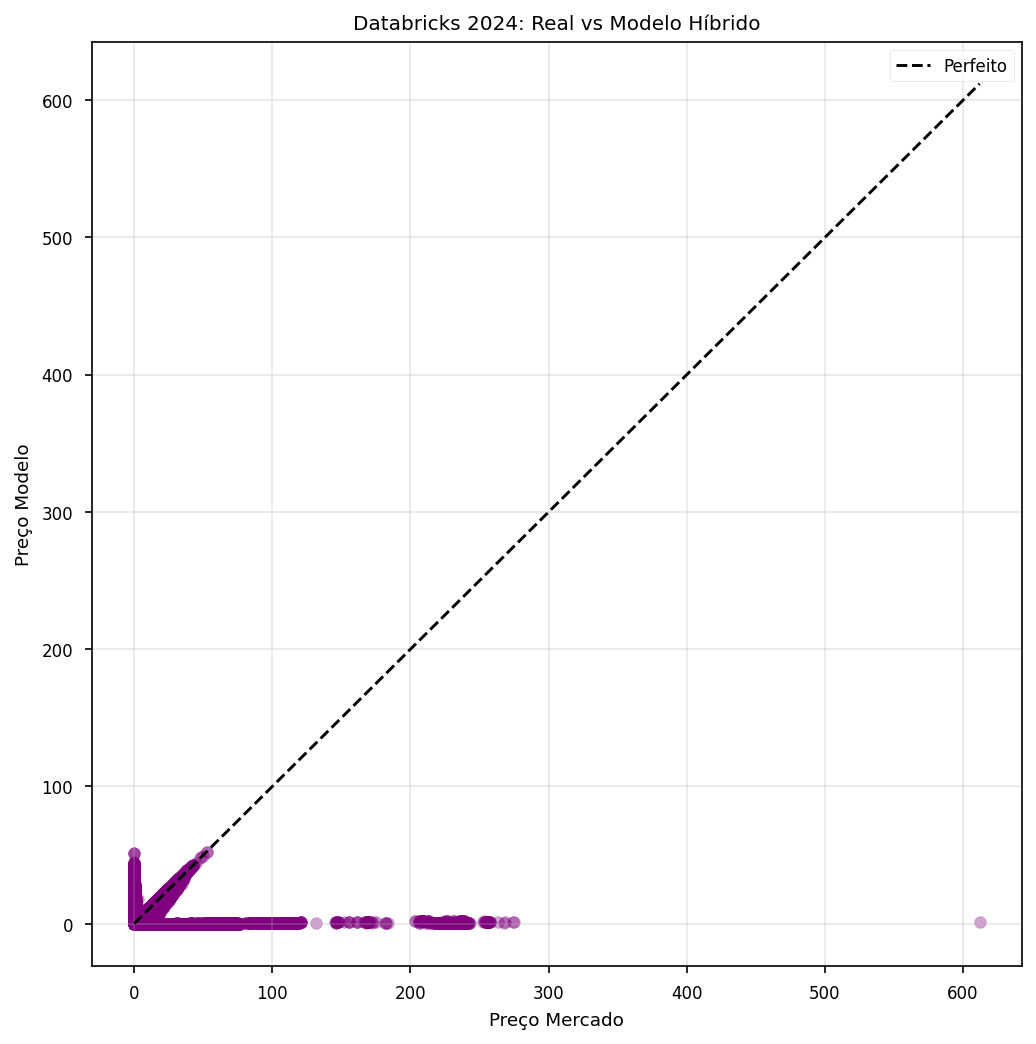

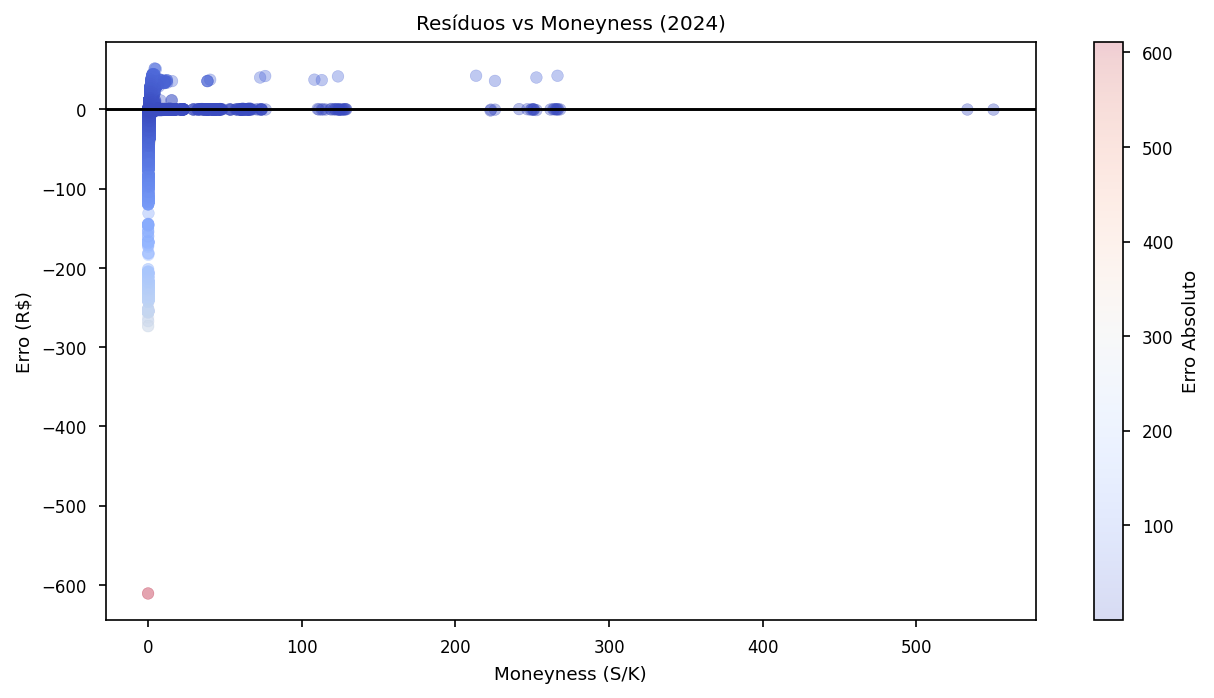

In [56]:
# Célula 5: Plots de Validação 2024

# 1. Real vs Previsto (Scatter)
plt.figure(figsize=(8, 8))
plt.scatter(df_2024['Real'], df_2024['Previsto'], alpha=0.2, color='purple')
plt.plot([0, df_2024['Real'].max()], [0, df_2024['Real'].max()], 'k--', label='Perfeito')
plt.title('Databricks 2024: Real vs Modelo Híbrido')
plt.xlabel('Preço Mercado')
plt.ylabel('Preço Modelo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Erro por Moneyness (Onde o modelo erra mais?)
df_2024['Erro'] = df_2024['Previsto'] - df_2024['Real']
plt.figure(figsize=(10, 5))
plt.scatter(df_2024['Moneyness'], df_2024['Erro'], alpha=0.2, c=df_2024['Erro'].abs(), cmap='coolwarm')
plt.axhline(0, color='black')
plt.title('Resíduos vs Moneyness (2024)')
plt.xlabel('Moneyness (S/K)')
plt.ylabel('Erro (R$)')
plt.colorbar(label='Erro Absoluto')
plt.show()

## Análise da "Mente" da LSTM: Visualização da evolução da volatilidade latente e correlação aprendida.

### 4. Análise Visual da "Caixa Preta" (LSTM)
Esta é a parte nova e mais importante: ver se a LSTM aprendeu a dinâmica do mercado.

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Rubens Molina\AppData\Local\Temp\ipykernel_99556\3756697720.py:17: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_ylabel('Volatilidade ($\sqrt{nu_t}$)', color='orange')


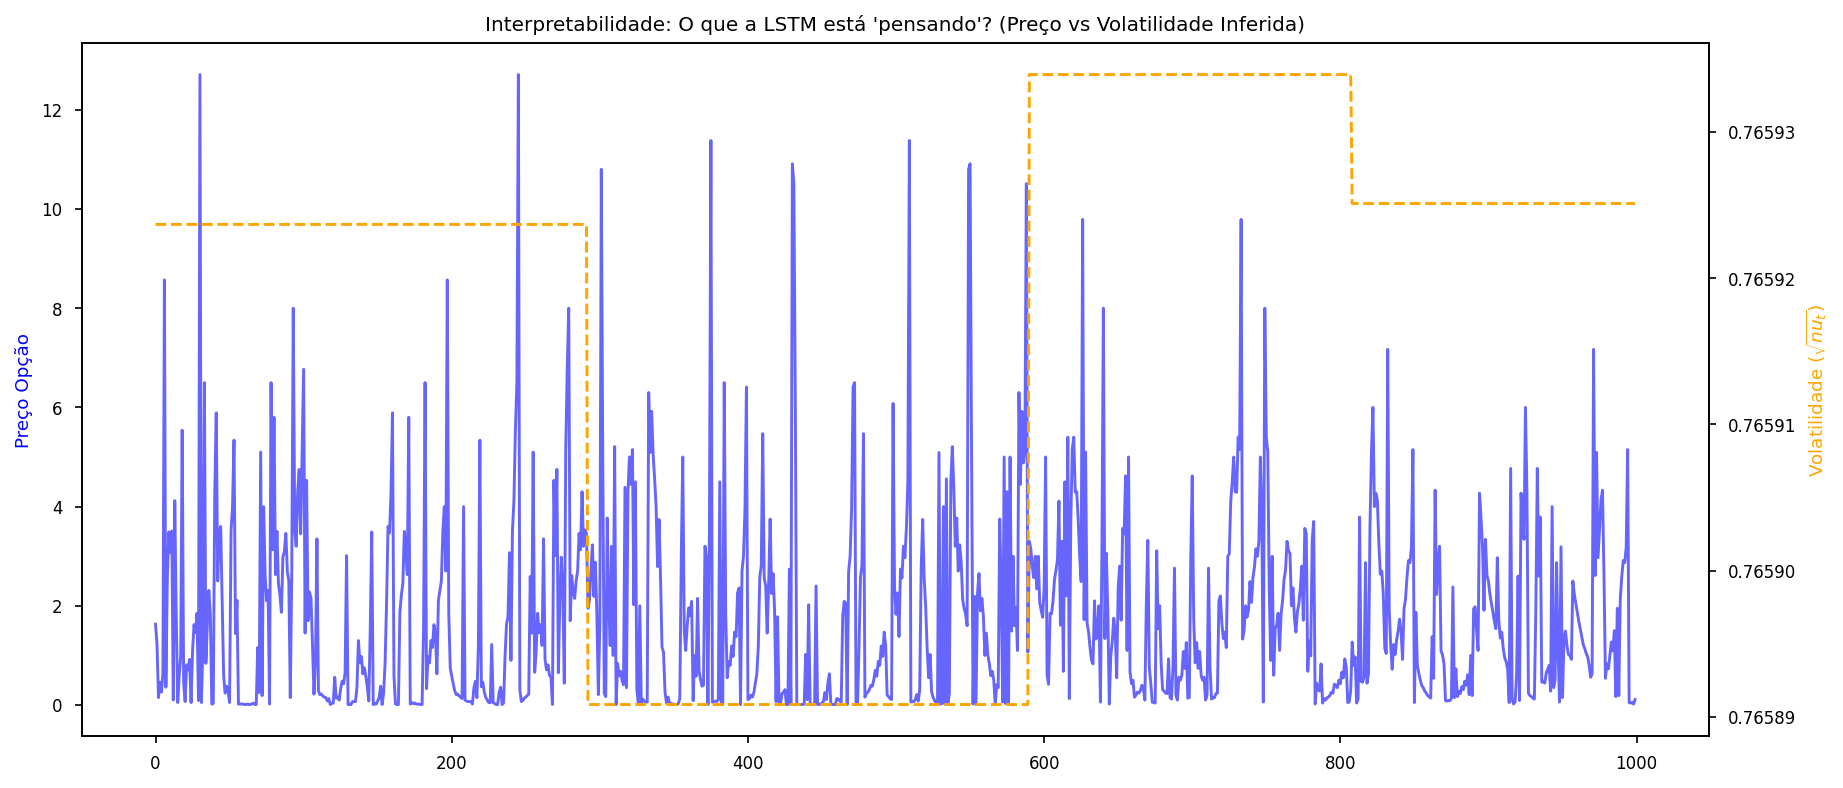

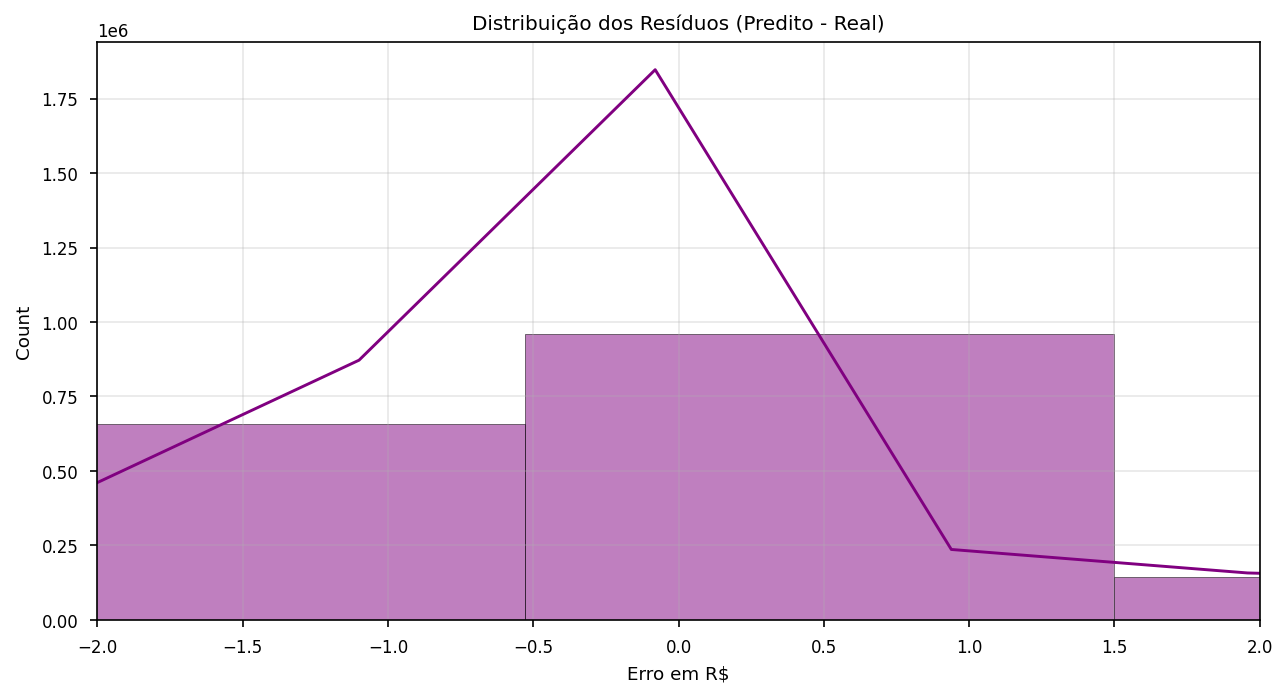

In [57]:
# Célula 4: Dinâmica da Volatilidade Latente
# Vamos plotar o preço do ativo vs. a volatilidade (nu) que a LSTM inferiu
# Se o modelo aprendeu Heston, quando o preço cai, a vol deve subir (efeito alavancagem)

plt.figure(figsize=(14, 6))

# Pegar uma amostra sequencial (os primeiros 500 pontos de um ativo específico se possível, 
# aqui pegamos geral para ilustrar a distribuição)
subset = df_res.iloc[:1000] 

ax1 = plt.gca()
ax1.plot(subset.index, subset['Real'], color='blue', label='Preço Opção (Real)', alpha=0.6)
ax1.set_ylabel('Preço Opção', color='blue')

ax2 = ax1.twinx()
ax2.plot(subset.index, np.sqrt(subset['Nu_Latente']), color='orange', label='Volatilidade Estocástica (LSTM)', linestyle='--')
ax2.set_ylabel('Volatilidade ($\sqrt{nu_t}$)', color='orange')

plt.title("Interpretabilidade: O que a LSTM está 'pensando'? (Preço vs Volatilidade Inferida)")
plt.show()

# Histograma do Erro
plt.figure(figsize=(10, 5))
sns.histplot(df_res['Erro'], bins=100, kde=True, color='purple')
plt.title('Distribuição dos Resíduos (Predito - Real)')
plt.xlabel('Erro em R$')
plt.xlim(-2, 2) # Zoom na região central
plt.grid(True, alpha=0.3)
plt.show()

## Validação Backtest (2024): Teste de estresse em ativos específicos fora da amostra.

### 5. Validação Out-Of-Sample (2024) - Ativos Distintos
Aqui você define quais arquivos de 2024 quer testar.

In [58]:
# Célula 5 (Corrigida): Validação Completa com Tratamento de Erros e Limpeza

from scipy.stats import norm

def black_scholes_vectorized(S, K, T, r, sigma, option_type='call'):
    """Cálculo vetorizado de Black-Scholes para Benchmark."""
    # Proteções numéricas
    S = np.maximum(S, 1e-5) # Evita log(0)
    K = np.maximum(K, 1e-5) # Evita divisão por zero
    T = np.maximum(T, 1e-5) # Evita divisão por zero no d1/d2
    sigma = np.maximum(sigma, 1e-5) # Evita vol zero
    
    try:
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        
        if option_type == 'call':
            price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        else:
            price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        return price
    except Exception as e:
        print(f"Aviso: Erro no cálculo BS: {e}")
        return np.zeros_like(S)

def testar_ativo_2024(nome_ativo):
    print(f"--- Iniciando Backtest Avançado: {nome_ativo} (2024) ---")
    
    # 1. Configuração de Caminhos
    pasta_2024 = os.path.join(PATHS['raw_data'], 'Databricks', '2024')
    
    if not os.path.exists(pasta_2024):
        # Tenta fallback para a pasta pai se a subpasta 2024 não existir
        pasta_alternativa = os.path.join(PATHS['raw_data'], 'Databricks')
        if os.path.exists(pasta_alternativa):
            print(f"Aviso: Pasta '2024' não encontrada. Usando: {pasta_alternativa}")
            pasta_2024 = pasta_alternativa
        else:
            print(f"ERRO CRÍTICO: Pasta de dados não encontrada em {pasta_2024}")
            return

    # 2. Carregar Dados
    # Usa 'train_stats' se disponível (da Célula 3), senão 'data_stats'
    stats_global = train_stats if 'train_stats' in globals() else data_stats
    
    # Chama sua função customizada
    ds_2024, _ = criar_dataset_test(
        pasta_2024, 
        df_juros, 
        DATA_CONFIG['sequence_length'], 
        stats_global,
        ativo_alvo=nome_ativo
    )
    
    if ds_2024 is None:
        print("Nenhum dado encontrado ou carregado.")
        return

    # 3. Inferência
    loader = DataLoader(ds_2024, batch_size=4096, shuffle=False)
    
    res = {k: [] for k in ['real', 'pred', 'time', 'strike', 'spot', 'T', 'r', 'nu', 'hist_vol']}
    
    with torch.no_grad():
        for batch in loader:
            x_seq = batch[0].to(device)
            x_phy_raw = batch[1].to(device) 
            y_norm = batch[2].to(device)
            times = batch[3]
            
            # Normalização Manual para a PINN
            S_norm = (x_phy_raw[:, 0:1] - stats_global['S_min']) / (stats_global['S_max'] - stats_global['S_min'])
            K_norm = (x_phy_raw[:, 1:2] - stats_global['K_min']) / (stats_global['K_max'] - stats_global['K_min'])
            T_norm = x_phy_raw[:, 2:3] / stats_global['T_max']
            r_raw = x_phy_raw[:, 3:4]
            
            x_phy_input = torch.cat([S_norm, K_norm, T_norm, r_raw], dim=1)
            
            # Forward
            out = model(x_seq, x_phy_input)
            
            # Dados Reais (Desnormalizados) para guardar
            K_real = x_phy_raw[:, 1:2]
            S_real = x_phy_raw[:, 0:1]
            T_real = x_phy_raw[:, 2:3]
            r_real = x_phy_raw[:, 3:4]
            
            price_pred = out['price'] * K_real
            price_real = y_norm * K_real
            
            nu_latente = out['heston_params'][0]
            hist_vol = x_seq[:, -1, 1:2] # Feature de volatilidade da LSTM
            
            # Coleta (CPU)
            res['real'].extend(price_real.cpu().numpy().flatten())
            res['pred'].extend(price_pred.cpu().numpy().flatten())
            res['time'].extend(times.numpy().flatten())
            res['strike'].extend(K_real.cpu().numpy().flatten())
            res['spot'].extend(S_real.cpu().numpy().flatten())
            res['T'].extend(T_real.cpu().numpy().flatten())
            res['r'].extend(r_real.cpu().numpy().flatten())
            res['nu'].extend(nu_latente.cpu().numpy().flatten())
            res['hist_vol'].extend(hist_vol.cpu().numpy().flatten())

    # Criar DataFrame
    df = pd.DataFrame(res)
    df['Data'] = pd.to_datetime(df['timestamp'] if 'timestamp' in df else df['time'], unit='s')
    df = df.sort_values('Data')
    
    # --- LIMPEZA DE DADOS (A CORREÇÃO PRINCIPAL) ---
    # Remove dados corrompidos (spot <=0, strike <=0) que quebram o log
    initial_len = len(df)
    df = df[(df['spot'] > 0.01) & (df['strike'] > 0.01) & (df['T'] > 0.001)]
    
    # Trata Volatilidade Nula/NaN
    df['hist_vol'] = df['hist_vol'].fillna(0.3) # Assume 30% se vazio
    df['hist_vol'] = df['hist_vol'].replace(0, 0.3) # Substitui zeros
    
    # 4. Calcular Benchmark Black-Scholes
    df['BS_Price'] = black_scholes_vectorized(
        df['spot'].values, df['strike'].values, df['T'].values, 
        df['r'].values, df['hist_vol'].values
    )
    
    # Remove NaNs que possam ter surgido no BS ou na Predição
    df.dropna(subset=['real', 'pred', 'BS_Price'], inplace=True)
    
    print(f"Dados limpos: {len(df)} registros (Removidos {initial_len - len(df)} inválidos).")
    
    if df.empty:
        print("ERRO: Todos os dados foram filtrados. Verifique a qualidade dos dados de entrada.")
        return

    # Métricas
    r2_model = r2_score(df['real'], df['pred'])
    r2_bs = r2_score(df['real'], df['BS_Price'])
    mae_model = mean_absolute_error(df['real'], df['pred'])
    mae_bs = mean_absolute_error(df['real'], df['BS_Price'])
    
    print(f"\n=== RESULTADOS COMPARATIVOS ({nome_ativo}) ===")
    print(f"Modelo Híbrido -> MAE: {mae_model:.4f} | R²: {r2_model:.4f}")
    print(f"Black-Scholes  -> MAE: {mae_bs:.4f} | R²: {r2_bs:.4f}")
    
    # ==========================================
    # PLOTS
    # ==========================================
    
    # 1. Backtest Temporal (Preço Real vs Previsto)
    plt.figure(figsize=(14, 5))
    daily = df.groupby('Data')[['real', 'pred']].mean()
    plt.plot(daily.index, daily['real'], label='Mercado (Real)', color='black', linewidth=1.5)
    plt.plot(daily.index, daily['pred'], label='Modelo Híbrido', color='#2ca02c', linestyle='--', linewidth=1.5)
    plt.title(f'Backtest Temporal: {nome_ativo} 2024')
    plt.ylabel('Preço da Opção (R$)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 2. Comparativo (Amostra)
    plt.figure(figsize=(14, 5))
    subset = df.sample(n=min(150, len(df))).sort_values('spot')
    x_idx = range(len(subset))
    plt.scatter(x_idx, subset['real'], label='Mercado', color='gray', alpha=0.5)
    plt.plot(x_idx, subset['BS_Price'], label='Black-Scholes', color='blue', linestyle=':', alpha=0.7)
    plt.plot(x_idx, subset['pred'], label='DeepHeston', color='red', linewidth=1.5)
    plt.title('Comparativo de Precificação (Amostra Aleatória)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 3. Dinâmica de Volatilidade
    plt.figure(figsize=(14, 5))
    vol_latente = np.sqrt(np.maximum(df['nu'], 0))
    daily_vol = df.groupby('Data').agg({'hist_vol': 'mean', 'nu': 'mean'})
    daily_vol['latente'] = np.sqrt(daily_vol['nu'])
    
    plt.plot(daily_vol.index, daily_vol['hist_vol'], label='Vol Histórica (Input)', color='gray', linestyle=':')
    plt.plot(daily_vol.index, daily_vol['latente'], label='Vol Latente (Aprendida)', color='purple', linewidth=2)
    plt.title('Dinâmica da Volatilidade (Latente vs Histórica)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



--- Iniciando Backtest Avançado: PETR4 (2024) ---
Procurando arquivos de PETR4 em: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\dados\brutos\Databricks\2024
Carregado: PETR4_2024.csv
Dados 2024 carregados: 314460 registros.
Dados limpos: 272504 registros (Removidos 6272 inválidos).

=== RESULTADOS COMPARATIVOS (PETR4) ===
Modelo Híbrido -> MAE: 0.0967 | R²: -8.5777
Black-Scholes  -> MAE: 0.0982 | R²: -8.8259


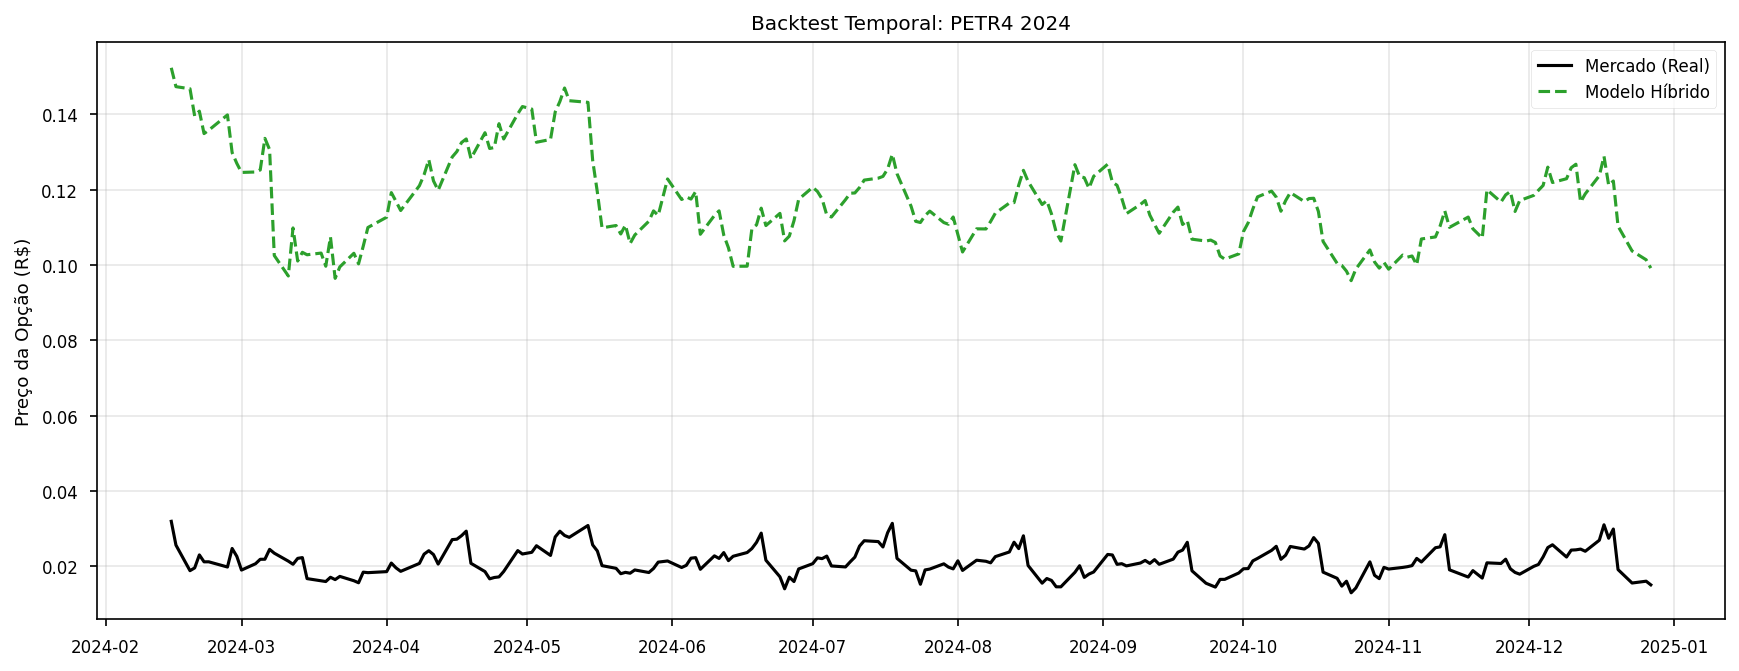

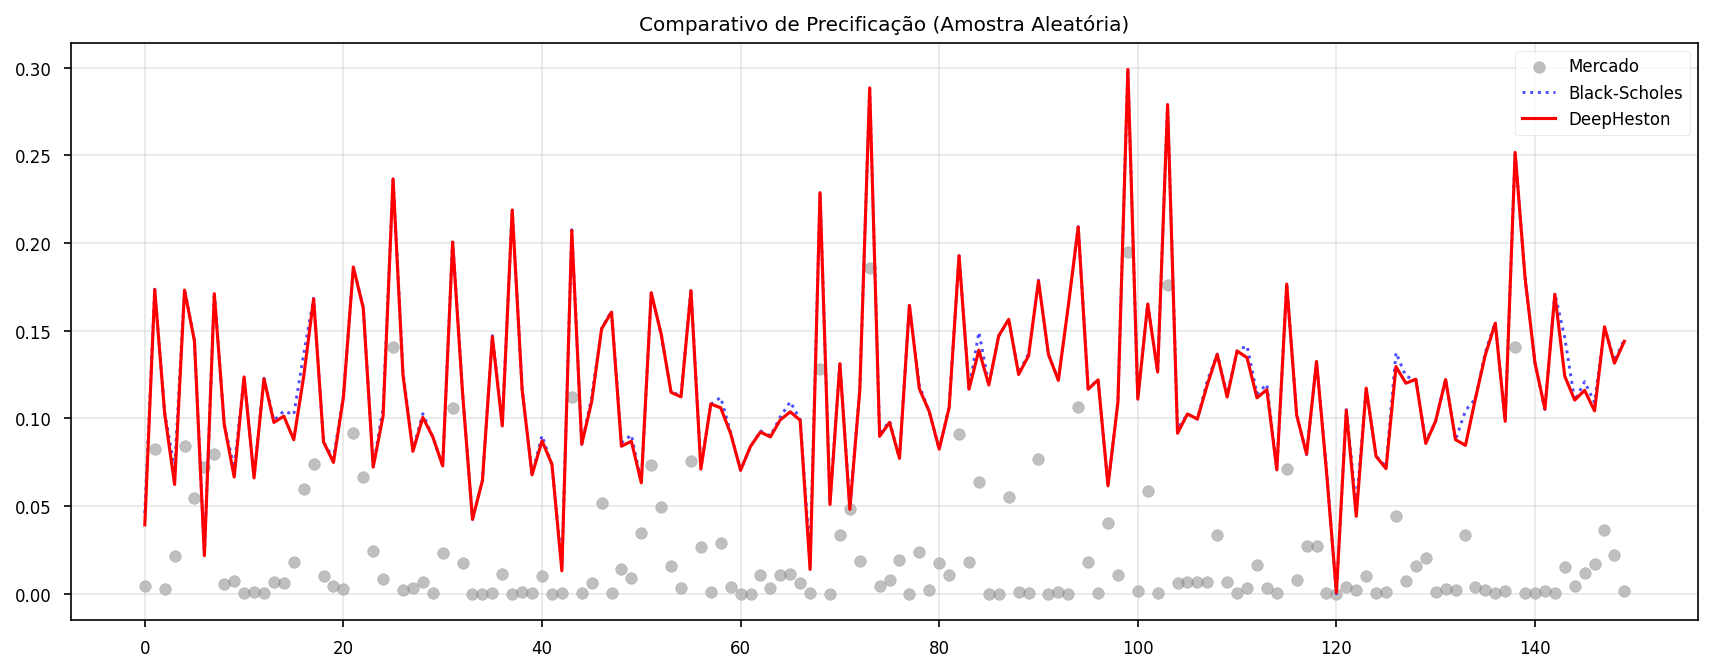

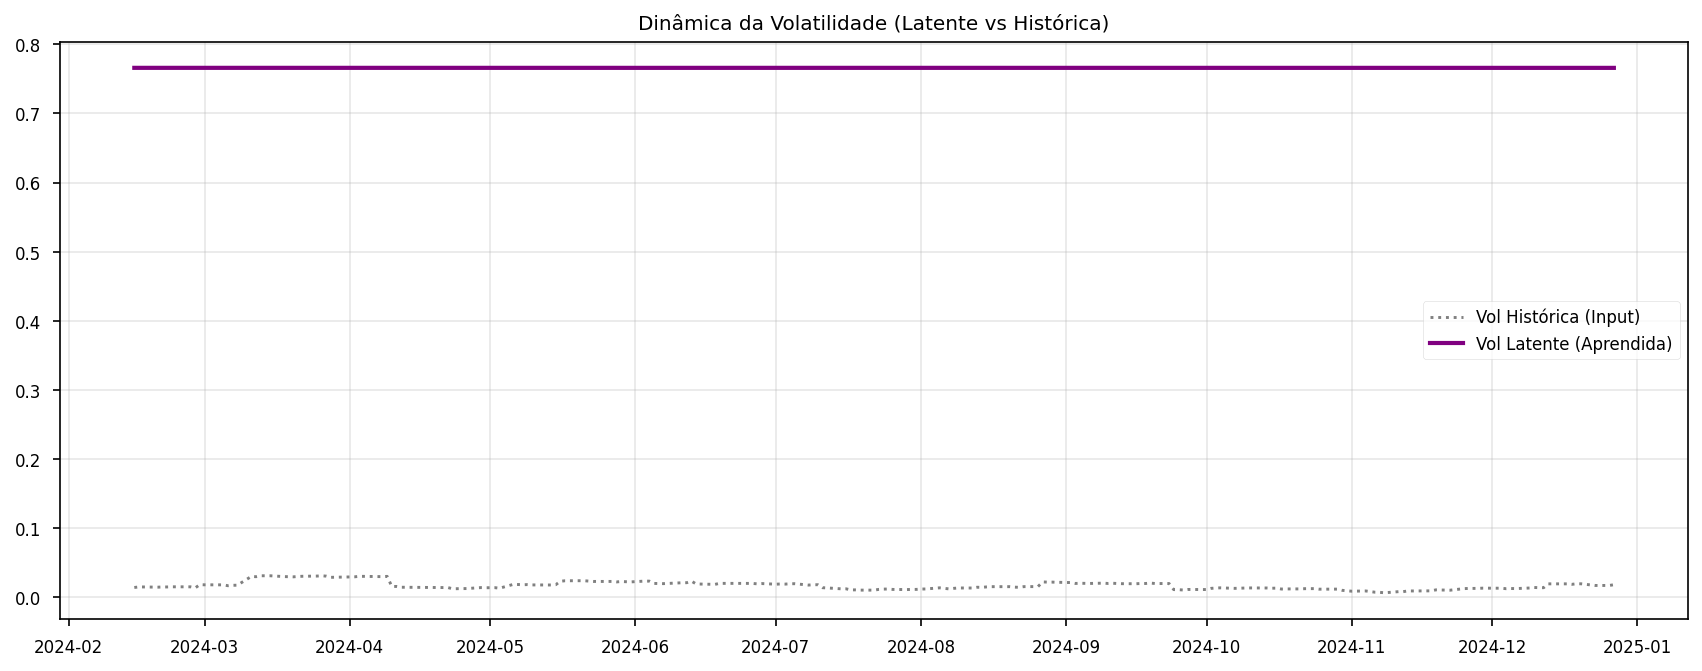

In [59]:
testar_ativo_2024('PETR4')


--- Iniciando Backtest Avançado: VALE3 (2024) ---
Procurando arquivos de VALE3 em: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\dados\brutos\Databricks\2024
Carregado: VALE3_2024.csv
Dados 2024 carregados: 218114 registros.
Dados limpos: 188898 registros (Removidos 3620 inválidos).

=== RESULTADOS COMPARATIVOS (VALE3) ===
Modelo Híbrido -> MAE: 0.1444 | R²: -5.4234
Black-Scholes  -> MAE: 0.1473 | R²: -5.6155


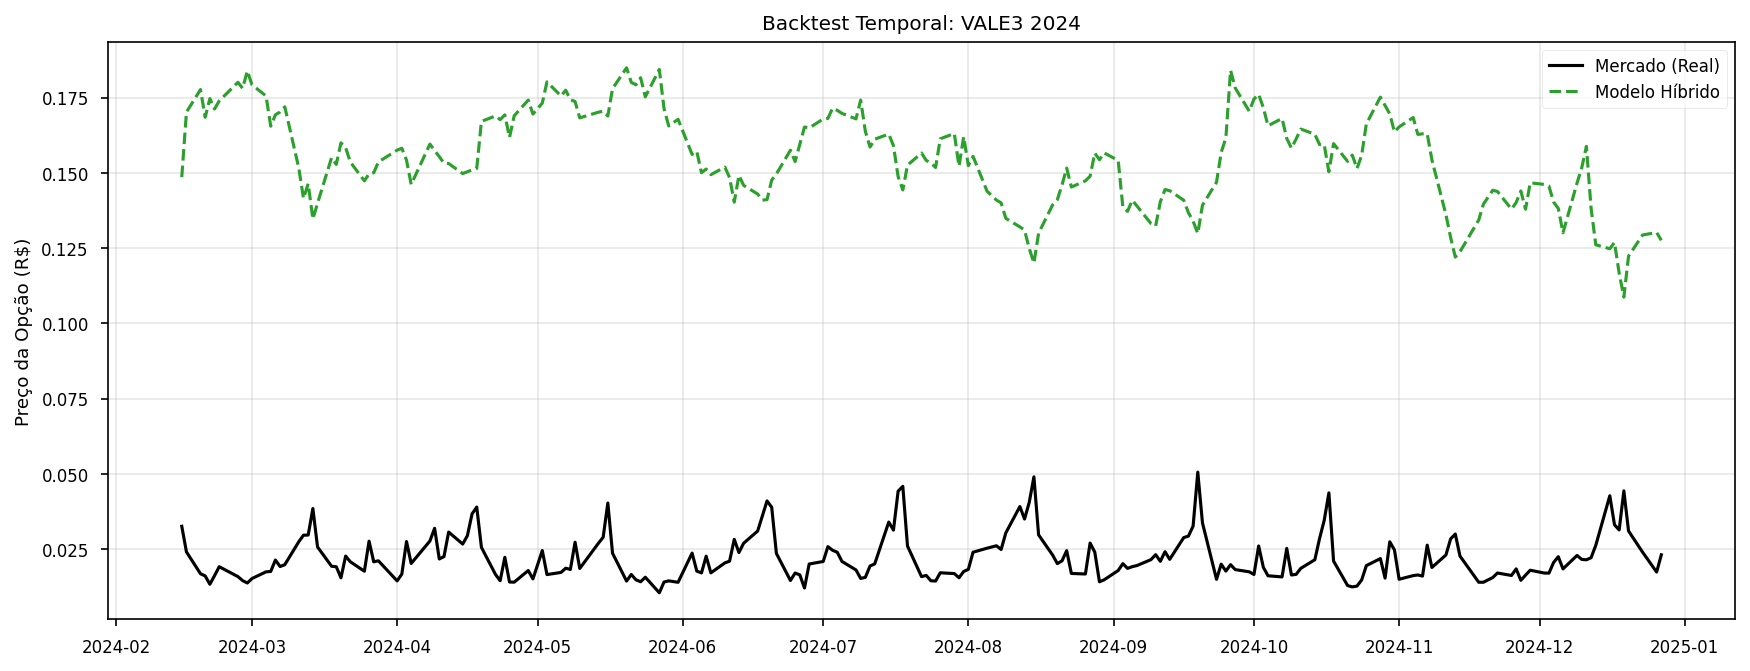

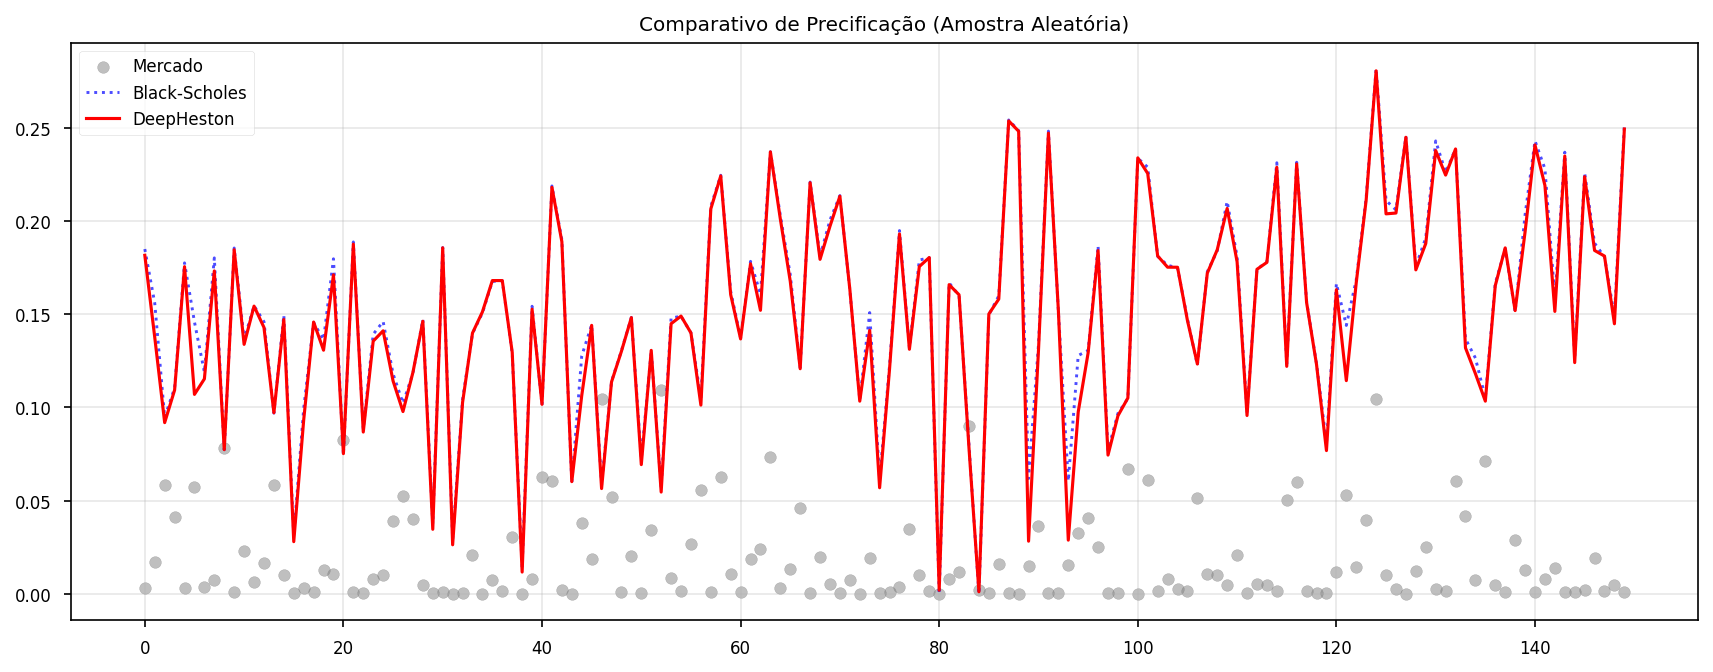

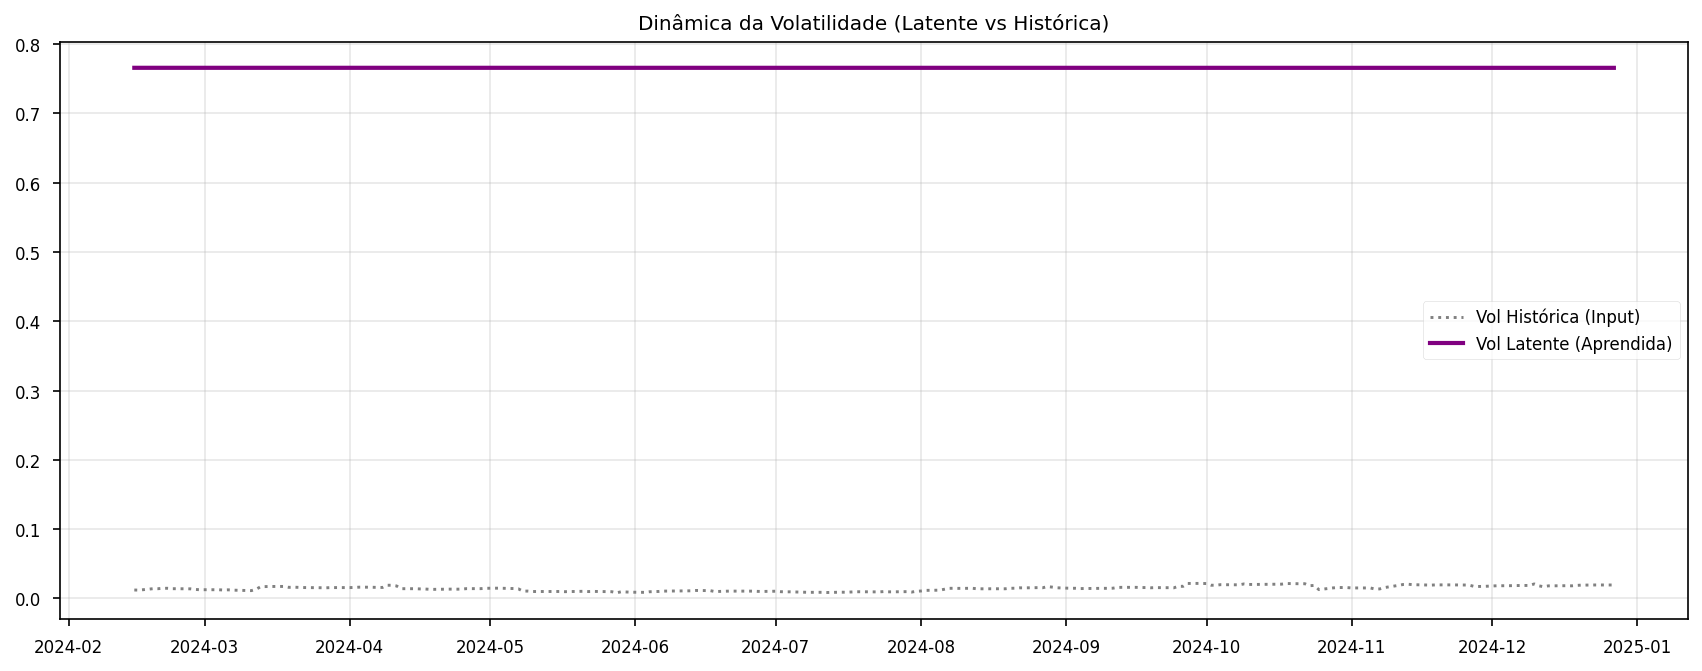

In [60]:

testar_ativo_2024('VALE3')

--- Iniciando Backtest Avançado: BBDC4 (2024) ---
Procurando arquivos de BBDC4 em: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\dados\brutos\Databricks\2024
Carregado: BBDC4_2024.csv
Dados 2024 carregados: 112664 registros.
Dados limpos: 97296 registros (Removidos 1968 inválidos).

=== RESULTADOS COMPARATIVOS (BBDC4) ===
Modelo Híbrido -> MAE: 0.0243 | R²: -3.2008
Black-Scholes  -> MAE: 0.0250 | R²: -3.3643


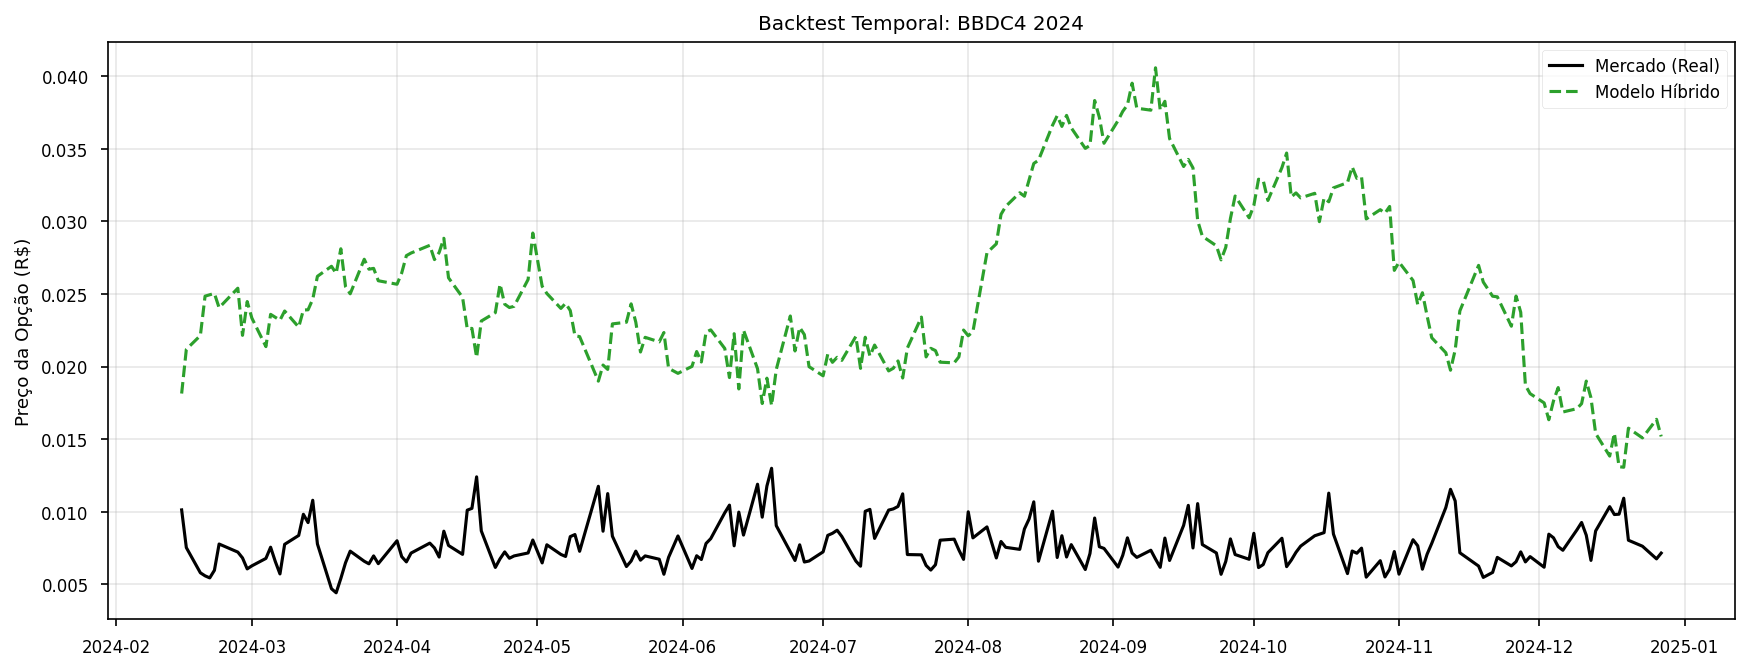

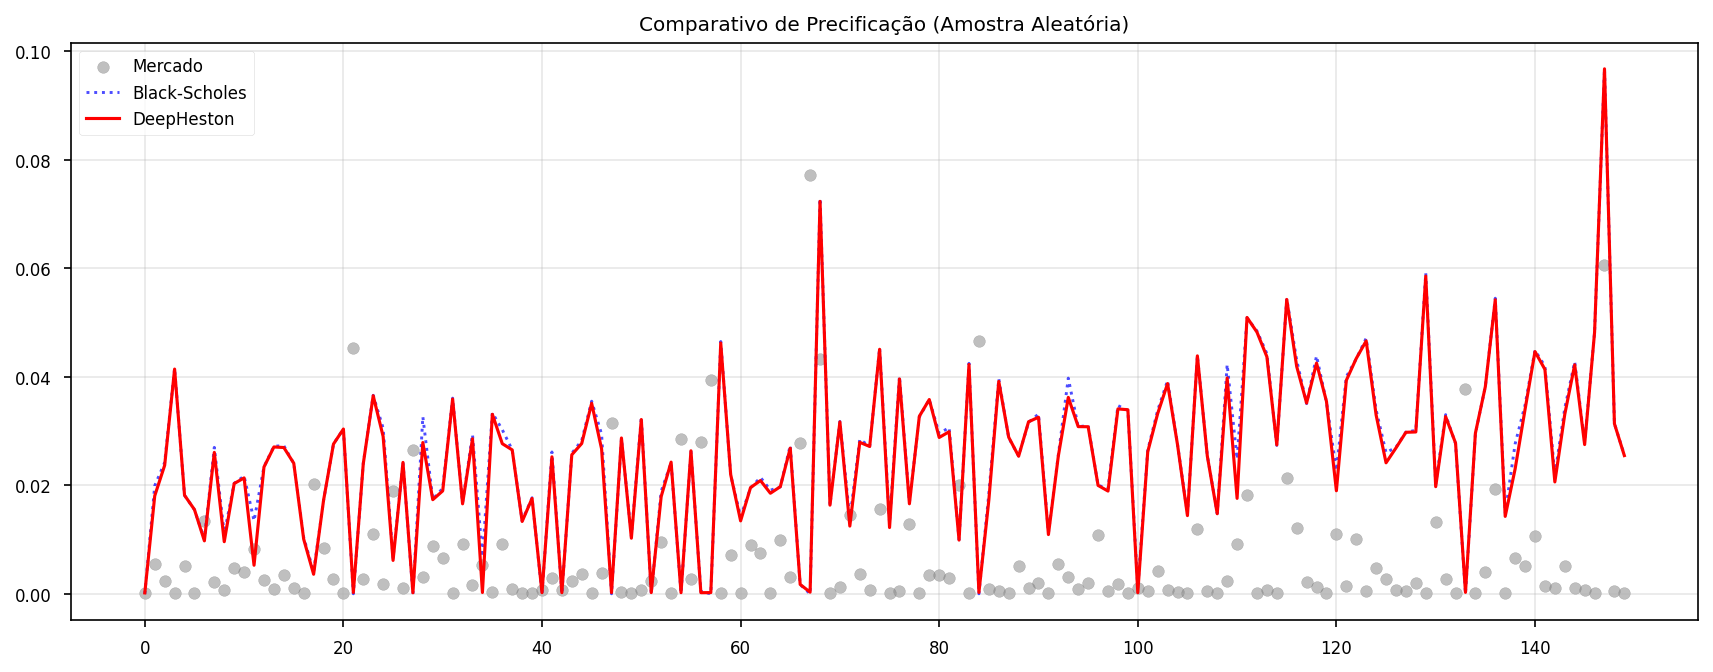

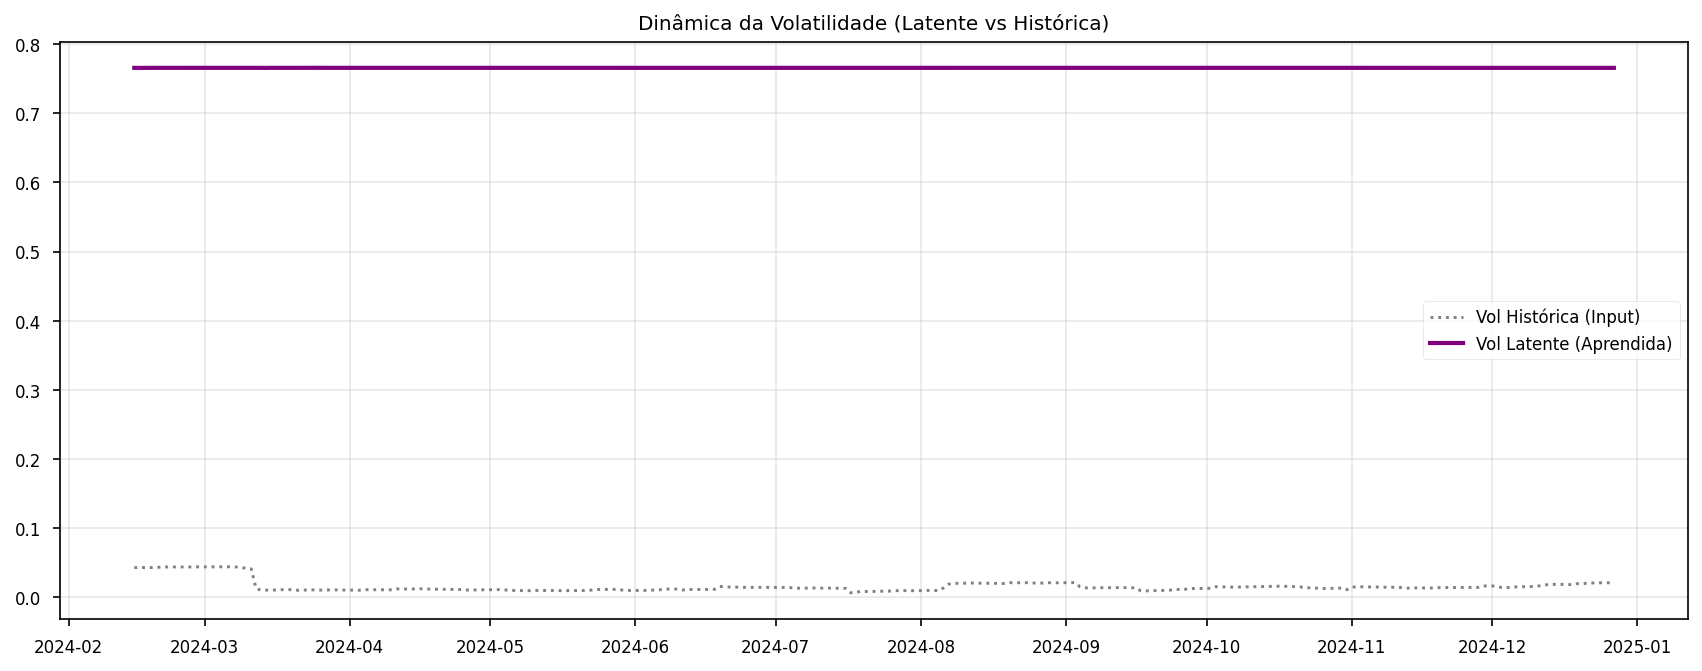

In [61]:
testar_ativo_2024('BBDC4')